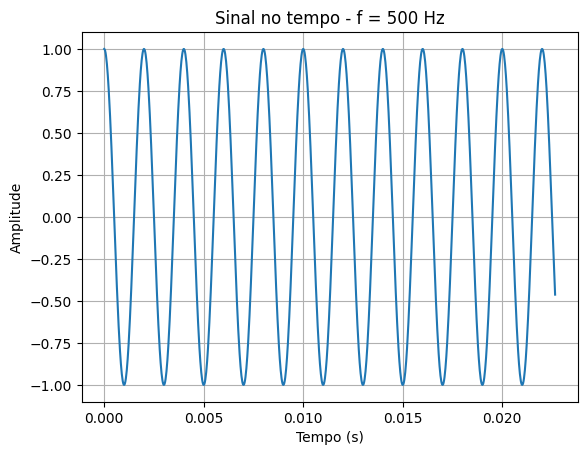

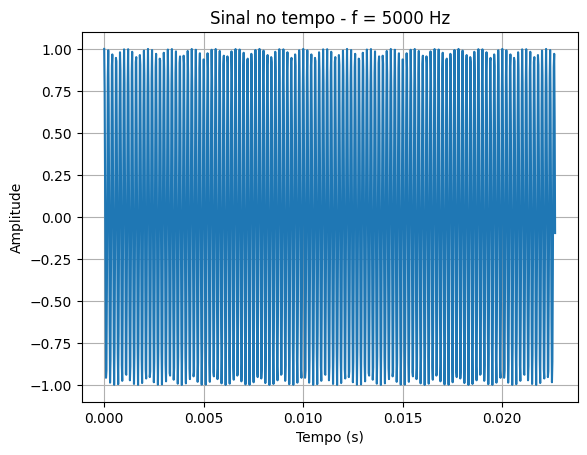

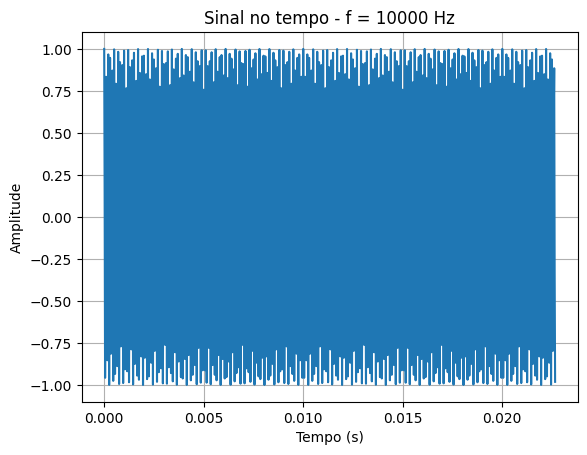

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

# Frequência de amostragem (Hz)
fs = 44100

# Duração do sinal (segundos)
duracao = 5

# Vetor de tempo
t = np.linspace(0, duracao, int(fs * duracao), endpoint=False)

# Frequências do sinal
frequencias = [500, 5000, 10000]

# Loop para gerar e plotar os sinais
for f in frequencias:
    # x(t) = cos(2πft)
    x = np.cos(2 * np.pi * f * t)

    # Plot (mostrando só os primeiros 5 ms pra visualizar melhor)
    plt.figure()
    plt.plot(t[:1000], x[:1000])
    plt.title(f"Sinal no tempo - f = {f} Hz")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

    # Reproduzir áudio
    display(Audio(x, rate=fs))

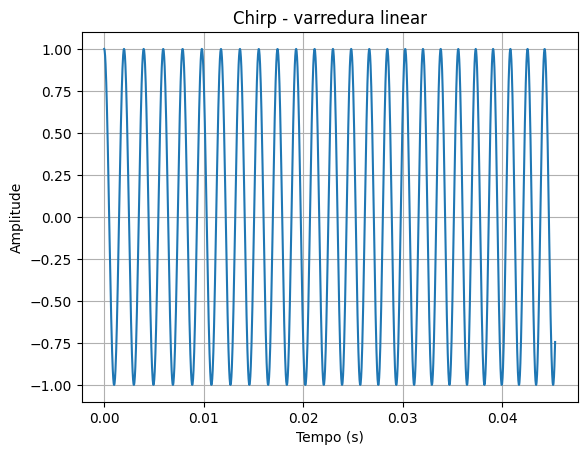

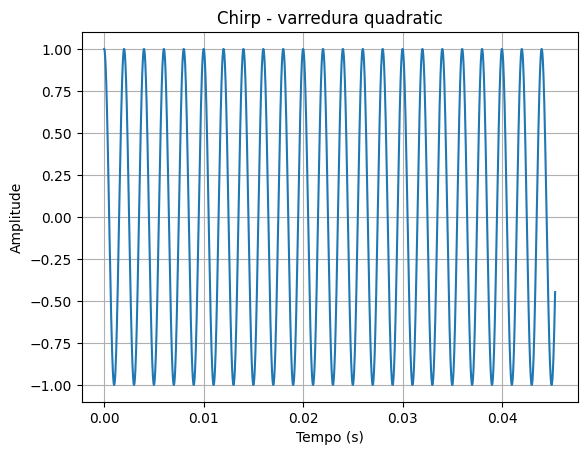

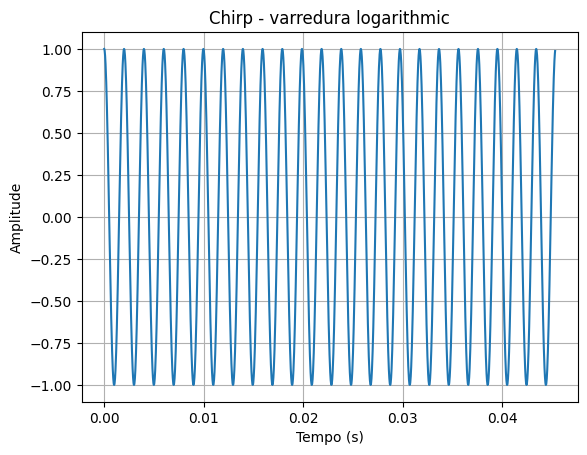

In [2]:
from scipy.signal import chirp

# Parâmetros
f0 = 500        # frequência inicial
f1 = 10000      # frequência final
duracao = 5
fs = 44100

t = np.linspace(0, duracao, int(fs * duracao), endpoint=False)

tipos = ['linear', 'quadratic', 'logarithmic']

for tipo in tipos:
    # Geração do chirp
    sinal = chirp(t, f0=f0, f1=f1, t1=duracao, method=tipo)

    # Plot
    plt.figure()
    plt.plot(t[:2000], sinal[:2000])
    plt.title(f"Chirp - varredura {tipo}")
    plt.xlabel("Tempo (s)")
    plt.ylabel("Amplitude")
    plt.grid()
    plt.show()

    # Áudio
    display(Audio(sinal, rate=fs))

Saving handel.wav to handel.wav


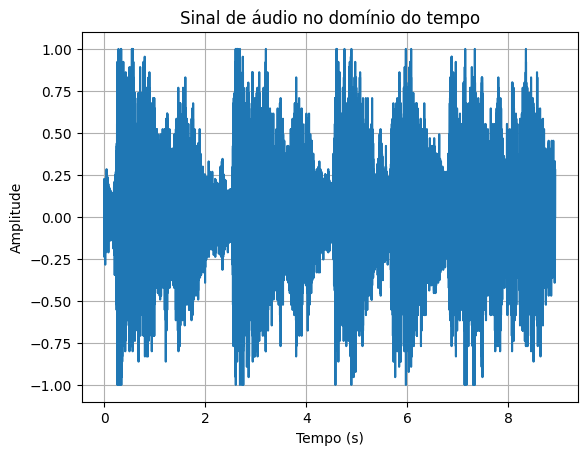

Frequência original


Dobro da frequência de amostragem


Quádruplo da frequência de amostragem


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from IPython.display import Audio
from google.colab import files  # módulo para upload

# Upload do arquivo
uploaded = files.upload()

# Nome do arquivo
nome_arquivo = 'handel.wav'

# Leitura do áudio
fs, audio = wav.read(nome_arquivo)

# Normalização
audio = audio / np.max(np.abs(audio))

# Vetor de tempo
t = np.linspace(0, len(audio)/fs, len(audio))

# Plot do sinal
plt.figure()
plt.plot(t, audio)
plt.title("Sinal de áudio no domínio do tempo")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Reprodução em diferentes frequências
print("Frequência original")
display(Audio(audio, rate=fs))

print("Dobro da frequência de amostragem")
display(Audio(audio, rate=fs*2))

print("Quádruplo da frequência de amostragem")
display(Audio(audio, rate=fs*4))

Saving h_banheiro.wav to h_banheiro (1).wav
Saving sinal_taca.wav to sinal_taca.wav
Arquivos enviados: ['h_banheiro (1).wav', 'sinal_taca.wav']


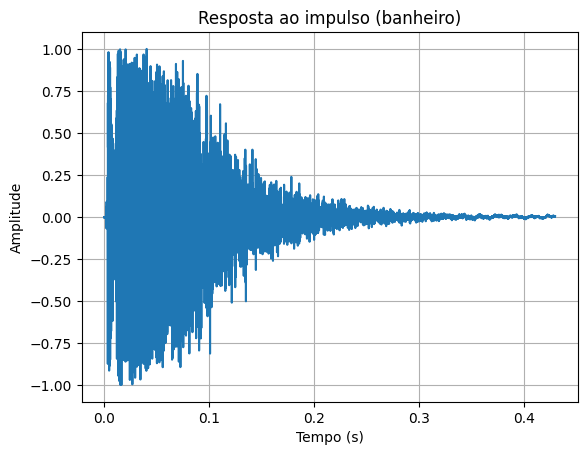

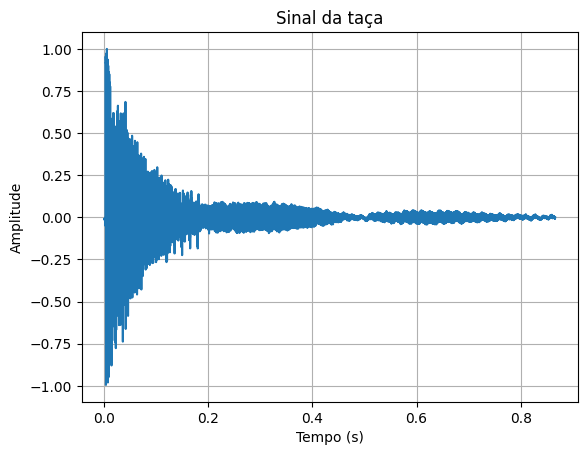

Resposta ao impulso:


Sinal da taça:


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from IPython.display import Audio
from google.colab import files

# Upload dos arquivos
uploaded = files.upload()

# Pegando nomes automaticamente
nomes = list(uploaded.keys())

print("Arquivos enviados:", nomes)

# Identificando os arquivos
arquivo_h = [n for n in nomes if 'banheiro' in n.lower()][0]
arquivo_taca = [n for n in nomes if 'taca' in n.lower()][0]

# Leitura dos sinais
fs_h, h = wav.read(arquivo_h)
fs_t, taca = wav.read(arquivo_taca)

# Normalização
h = h / np.max(np.abs(h))
taca = taca / np.max(np.abs(taca))

# Vetores de tempo
t_h = np.linspace(0, len(h)/fs_h, len(h))
t_t = np.linspace(0, len(taca)/fs_t, len(taca))

# Plot resposta ao impulso
plt.figure()
plt.plot(t_h, h)
plt.title("Resposta ao impulso (banheiro)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Plot sinal da taça
plt.figure()
plt.plot(t_t, taca)
plt.title("Sinal da taça")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Reprodução
print("Resposta ao impulso:")
display(Audio(h, rate=fs_h))

print("Sinal da taça:")
display(Audio(taca, rate=fs_t))

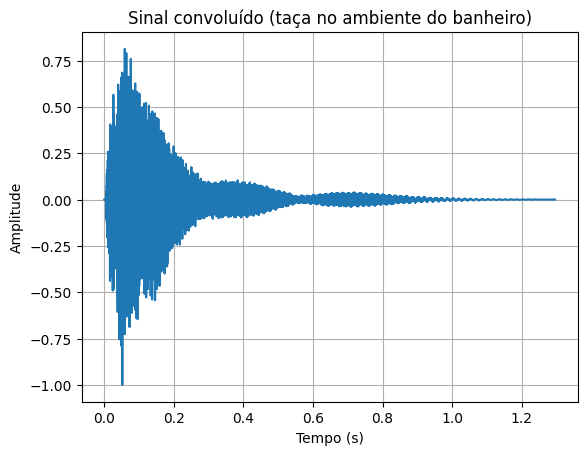

Resultado da convolução:


In [9]:
from scipy.signal import convolve

# Convolução
saida = convolve(taca, h, mode='full')

# Normalização
saida = saida / np.max(np.abs(saida))

# Vetor de tempo
t_saida = np.linspace(0, len(saida)/fs_h, len(saida))

# Plot
plt.figure()
plt.plot(t_saida, saida)
plt.title("Sinal convoluído (taça no ambiente do banheiro)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Reprodução
print("Resultado da convolução:")
display(Audio(saida, rate=fs_h))

Saving h_banheiro.wav to h_banheiro (4).wav
Saving handel.wav to handel (3).wav
Arquivos enviados: ['h_banheiro (4).wav', 'handel (3).wav']
Nova frequência de h: 8192 Hz


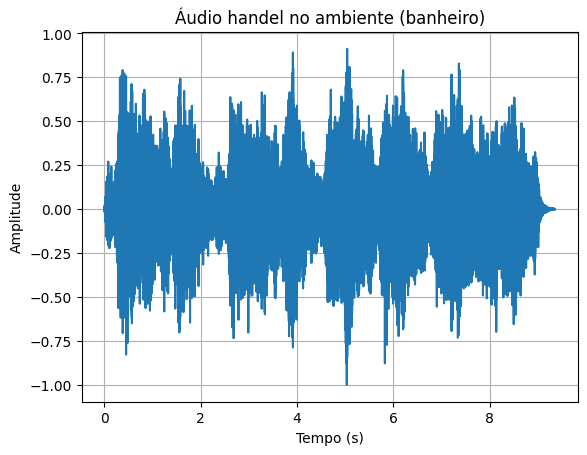

Áudio original:


Resposta ao impulso:


Áudio convoluído:


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile as wav
from scipy.signal import convolve, resample
from IPython.display import Audio
from google.colab import files

# Upload dos arquivos
uploaded = files.upload()

# Listar arquivos
nomes = list(uploaded.keys())
print("Arquivos enviados:", nomes)

# Identificação automática
arquivo_audio = None
arquivo_h = None

for nome in nomes:
    if "handel" in nome.lower():
        arquivo_audio = nome
    elif "banheiro" in nome.lower():
        arquivo_h = nome

if arquivo_audio is None or arquivo_h is None:
    raise ValueError("Envie 'handel.wav' e 'h_banheiro.wav'")

# Leitura
fs_x, x = wav.read(arquivo_audio)
fs_h, h = wav.read(arquivo_h)

# Converter para float
x = x.astype(float)
h = h.astype(float)

# Normalização
x = x / np.max(np.abs(x))
h = h / np.max(np.abs(h))

# Ajuste de frequência de amostragem
if fs_x != fs_h:

    # Vamos converter h para a mesma fs de x
    fator = fs_x / fs_h
    novo_tamanho = int(len(h) * fator)

    # Reamostragem
    h = resample(h, novo_tamanho)
    fs_h = fs_x

    print(f"Nova frequência de h: {fs_h} Hz")

# Convolução
y = convolve(x, h, mode='full')

# Normalizar saída
y = y / np.max(np.abs(y))

# Tempo
t_y = np.linspace(0, len(y)/fs_x, len(y))

# Plot
plt.figure()
plt.plot(t_y, y)
plt.title("Áudio handel no ambiente (banheiro)")
plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# Reprodução
print("Áudio original:")
display(Audio(x, rate=fs_x))

print("Resposta ao impulso:")
display(Audio(h, rate=fs_x))

print("Áudio convoluído:")
display(Audio(y, rate=fs_x))